In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [83]:
df=pd.read_csv("/content/sgd_dataset.csv")

In [84]:
df.head()

,feature_1,feature_2,target
0,-2.509198,-4.765886,13.540733
1,9.014286,-5.060424,50.429630
2,4.639879,8.125092,3.750870
3,1.973170,-5.009076,26.248770
4,-6.879627,-4.561005,-9.336945


In [85]:
X = df[['feature_1', 'feature_2']]
display(X.head())

,feature_1,feature_2
0,-2.509198,-4.765886
1,9.014286,-5.060424
2,4.639879,8.125092
3,1.973170,-5.009076
4,-6.879627,-4.561005


In [86]:
y = df['target']
display(y.head())

,target
0,13.540733
1,50.429630
2,3.750870
3,26.248770
4,-9.336945


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1600, 2)
X_test shape: (400, 2)
y_train shape: (1600,)
y_test shape: (400,)


In [88]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [89]:
y_pred = model.predict(X_test)

print("Model predictions on test set complete.")

Model predictions on test set complete.


In [90]:
model.coef_

array([ 3.48885365, -2.09518496])

In [91]:
model.intercept_

np.float64(6.91132541351797)

In [92]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 17.31
R-squared: 0.97


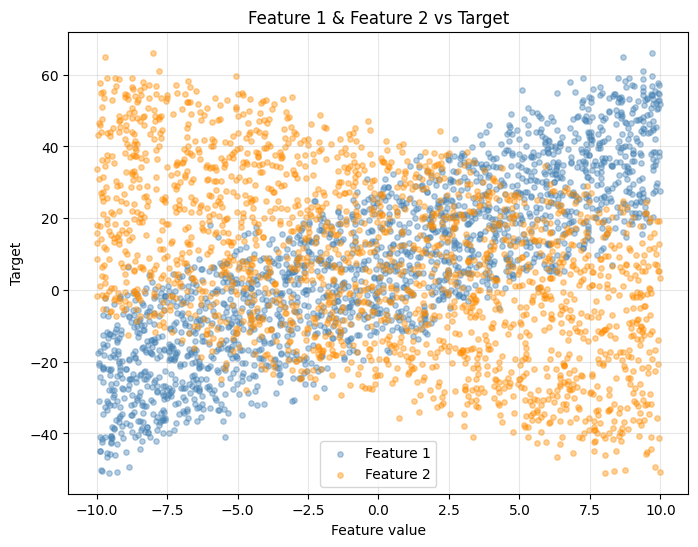

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('sgd_dataset.csv')  # adjust path if needed

plt.figure(figsize=(8, 6))

plt.scatter(df['feature_1'], df['target'], alpha=0.4, s=15, color='steelblue', label='Feature 1')
plt.scatter(df['feature_2'], df['target'], alpha=0.4, s=15, color='darkorange', label='Feature 2')

plt.xlabel('Feature value')
plt.ylabel('Target')
plt.title('Feature 1 & Feature 2 vs Target')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

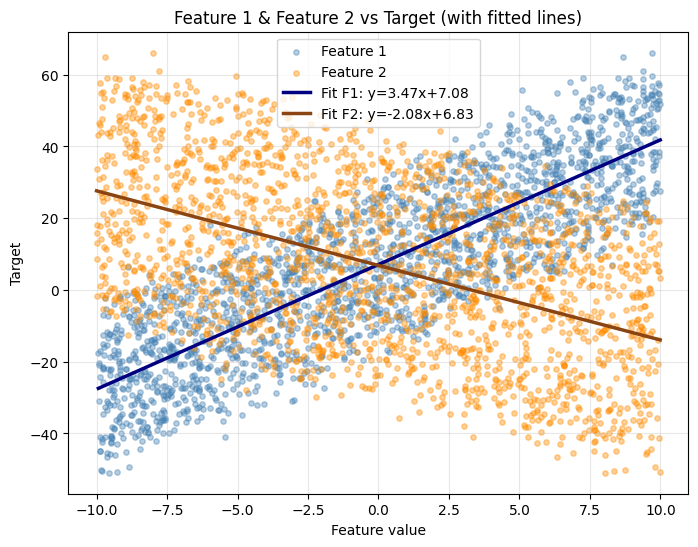

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('sgd_dataset.csv')  # adjust path if needed

plt.figure(figsize=(8, 6))

# Scatter points
plt.scatter(df['feature_1'], df['target'], alpha=0.4, s=15, color='steelblue', label='Feature 1')
plt.scatter(df['feature_2'], df['target'], alpha=0.4, s=15, color='darkorange', label='Feature 2')

# Fit simple 1D lines (target vs each feature independently)
m1, b1 = np.polyfit(df['feature_1'], df['target'], 1)
m2, b2 = np.polyfit(df['feature_2'], df['target'], 1)

x1_line = np.linspace(df['feature_1'].min(), df['feature_1'].max(), 100)
x2_line = np.linspace(df['feature_2'].min(), df['feature_2'].max(), 100)

plt.plot(x1_line, m1 * x1_line + b1, color='navy', lw=2.5, label=f'Fit F1: y={m1:.2f}x+{b1:.2f}')
plt.plot(x2_line, m2 * x2_line + b2, color='saddlebrown', lw=2.5, label=f'Fit F2: y={m2:.2f}x+{b2:.2f}')

plt.xlabel('Feature value')
plt.ylabel('Target')
plt.title('Feature 1 & Feature 2 vs Target (with fitted lines)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

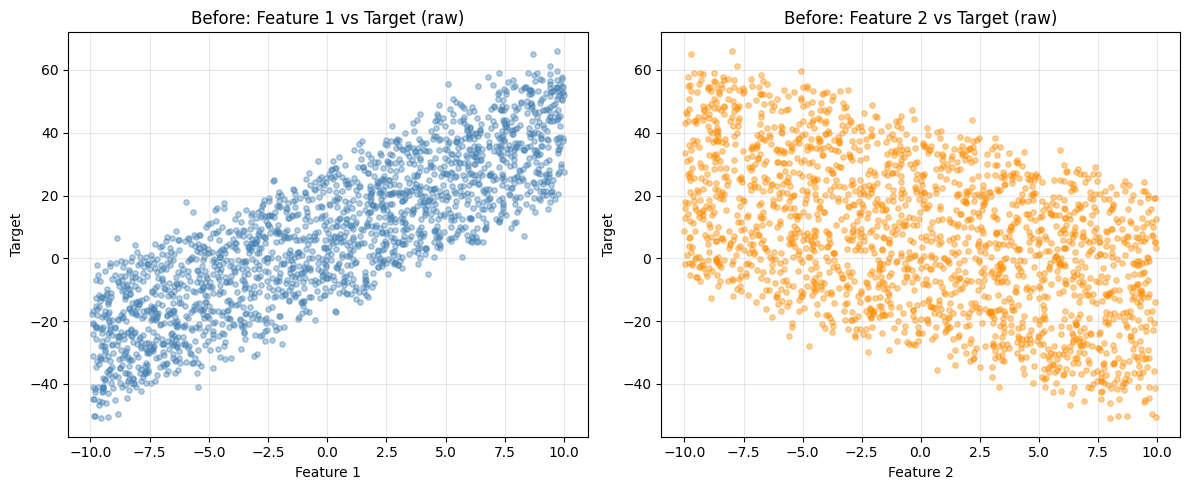

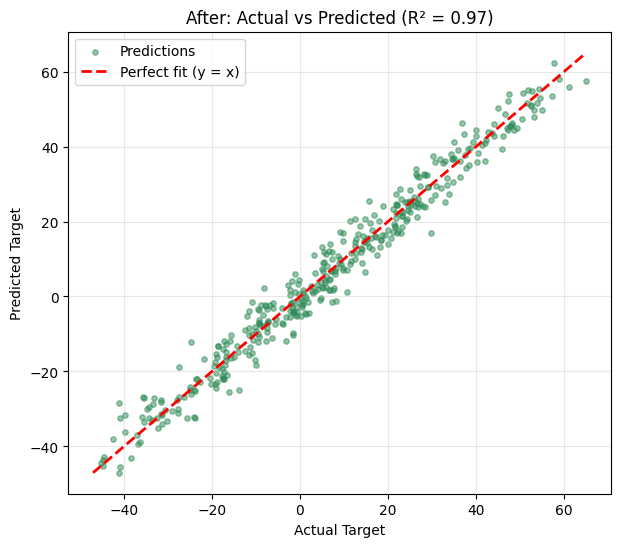

In [95]:
import matplotlib.pyplot as plt

# ---------- BEFORE: raw data ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['feature_1'], df['target'], alpha=0.4, s=15, color='steelblue')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Target')
axes[0].set_title('Before: Feature 1 vs Target (raw)')
axes[0].grid(alpha=0.3)

axes[1].scatter(df['feature_2'], df['target'], alpha=0.4, s=15, color='darkorange')
axes[1].set_xlabel('Feature 2')
axes[1].set_ylabel('Target')
axes[1].set_title('Before: Feature 2 vs Target (raw)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- AFTER: predicted vs actual ----------
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=15, color='seagreen', label='Predictions')

# perfect-prediction reference line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect fit (y = x)')

plt.xlabel('Actual Target')
plt.ylabel('Predicted Target')
plt.title(f'After: Actual vs Predicted (R² = {r2:.2f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Stochastic gradient from scratch


In [96]:
import random

In [114]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class SGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []      # track loss over iterations
        self.weights_history = []   # track weight evolution
        self.bias_history = []      # track bias evolution

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        if not isinstance(y, pd.Series):
            y = pd.Series(y)

        n = X.shape[0]

        for i in range(self.n_iterations):
            idx = random.randint(0, n - 1)

            y_hat = np.dot(X.iloc[idx], self.weights) + self.bias

            error = y.iloc[idx] - y_hat
            bias_gradient = -2 * error
            weights_gradient = -2 * error * X.iloc[idx]

            self.bias -= self.learning_rate * bias_gradient
            self.weights -= self.learning_rate * weights_gradient

            # record loss (squared error on the sampled point)
            self.loss_history.append(error ** 2)
            self.weights_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

        print(f"Final Intercept: {self.bias:.4f}, Final Coefficients: {self.weights.values}")

    def predict(self, X_test):
        if self.weights is None or self.bias is None:
            raise Exception("Model has not been fitted yet. Please call fit() first.")
        return np.dot(X_test, self.weights) + self.bias


# ---- Fixed variable name + more iterations for real convergence ----
sgd = SGD(learning_rate=0.001, n_iterations=3000)
sgd.fit(X_train, y_train)

Final Intercept: 6.9124, Final Coefficients: [ 3.50236976 -2.12289826]


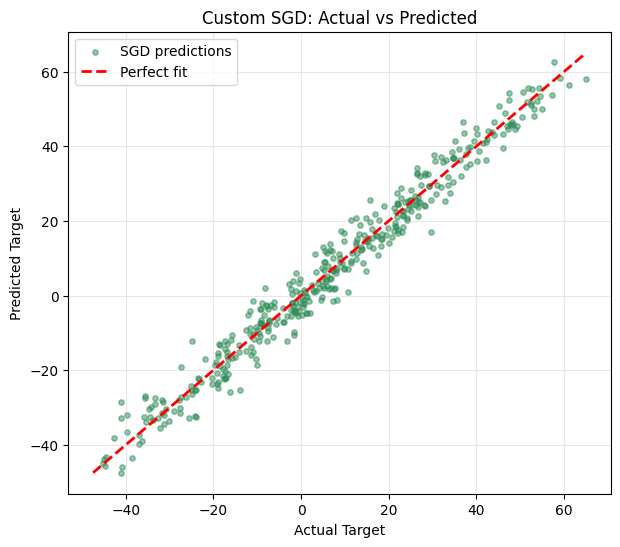

In [117]:


#Predicted vs Actual (custom SGD model)
y_pred_sgd = sgd.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_sgd, alpha=0.5, s=15, color='seagreen', label='SGD predictions')
min_val, max_val = min(y_test.min(), y_pred_sgd.min()), max(y_test.max(), y_pred_sgd.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect fit')
plt.xlabel('Actual Target')
plt.ylabel('Predicted Target')
plt.title('Custom SGD: Actual vs Predicted')
plt.legend()
plt.grid(alpha=0.3)
plt.show()